# EDA of combined energy demand and weather data

## Load and combine dataset

In [1]:
import pandas as pd

df_energy = pd.read_csv("../data/energy_demand_de_2019_2025.csv", parse_dates=['DateUTC'])
df_weather_all = pd.read_csv("../data/weather_data_mean_cities_2019_2025.csv", parse_dates=['DateUTC'])

# combine energy demand data with weather data, and save the combined dataset for future use
df_energy_weather = pd.concat([df_energy, df_weather_all], axis=1)
df_energy_weather = df_energy_weather.loc[:,~df_energy_weather.columns.duplicated()]

df_energy_weather = df_energy_weather.sort_values('DateUTC').reset_index(drop=True)

df_energy_weather.to_csv("../data/energy_weather_2019_2025.csv", index=False)

df_energy_weather.head()


,DateUTC,EnergyDemand,year,hour,weekday,month,is_weekend,is_holiday,holiday_ratio,apparent_temperature,rain,snowfall,wind_speed_10m,shortwave_radiation
0,2019-01-01 00:00:00,41653.9575,2019,0,1,1,0,1,0.0625,2.74,0.00,0.0,13.66,0.0
1,2019-01-01 01:00:00,40113.5800,2019,1,1,1,0,1,0.0625,2.72,0.00,0.0,14.04,0.0
2,2019-01-01 02:00:00,39312.9375,2019,2,1,1,0,1,0.0625,3.18,0.04,0.0,15.10,0.0
3,2019-01-01 03:00:00,39097.1625,2019,3,1,1,0,1,0.0625,2.78,0.02,0.0,16.46,0.0
4,2019-01-01 04:00:00,38634.3500,2019,4,1,1,0,1,0.0625,2.24,0.02,0.0,17.84,0.0


In [2]:
display(df_energy_weather.describe())
display(df_energy_weather.info())

,DateUTC,EnergyDemand,year,hour,weekday,month,is_weekend,is_holiday,holiday_ratio,apparent_temperature,rain,snowfall,wind_speed_10m,shortwave_radiation
count,59160,59160.000000,59160.000000,59160.000000,59160.000000,59160.000000,59160.000000,59160.000000,59160.000000,59160.000000,59160.000000,59160.000000,59160.000000,59160.000000
mean,2022-05-17 11:30:00.365111808,54663.227387,2021.888032,11.500101,2.999189,6.355375,0.285598,0.024341,0.001521,8.858622,0.092372,0.003722,11.963479,137.640429
min,2019-01-01 00:00:00,30908.880000,2019.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-15.080000,0.000000,0.000000,2.400000,0.000000
25%,2020-09-08 05:45:00,46803.277500,2020.000000,5.750000,1.000000,3.000000,0.000000,0.000000,0.000000,1.520000,0.000000,0.000000,8.440000,0.000000
50%,2022-05-17 11:30:00,54517.358750,2022.000000,11.500000,3.000000,6.000000,0.000000,0.000000,0.000000,8.180000,0.000000,0.000000,10.840000,8.800000
75%,2024-01-23 17:15:00,62177.330000,2024.000000,17.250000,5.000000,9.000000,1.000000,0.000000,0.000000,15.860000,0.100000,0.000000,14.340000,228.800000
max,2025-09-30 23:00:00,81077.455000,2025.000000,23.000000,6.000000,12.000000,1.000000,1.000000,0.062500,36.660000,3.760000,0.728000,40.920000,885.600000
std,NaN,9666.896304,1.949594,6.922113,2.000017,3.396644,0.451703,0.154106,0.009632,8.946438,0.200856,0.021976,4.956194,200.475408


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59160 entries, 0 to 59159
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   DateUTC               59160 non-null  datetime64[ns]
 1   EnergyDemand          59160 non-null  float64       
 2   year                  59160 non-null  int64         
 3   hour                  59160 non-null  int64         
 4   weekday               59160 non-null  int64         
 5   month                 59160 non-null  int64         
 6   is_weekend            59160 non-null  int64         
 7   is_holiday            59160 non-null  int64         
 8   holiday_ratio         59160 non-null  float64       
 9   apparent_temperature  59160 non-null  float64       
 10  rain                  59160 non-null  float64       
 11  snowfall              59160 non-null  float64       
 12  wind_speed_10m        59160 non-null  float64       
 13  shortwave_radiat

None

In [3]:
# feature engineering: create new features based on existing ones, such as rolling averages, lagged variables, or interaction terms
df_energy_weather['apparent_temperature_rolling_mean_24h'] = df_energy_weather['apparent_temperature'].shift(1).rolling(window=24).mean()
df_energy_weather['apparent_temperature_lag_24h'] = df_energy_weather['apparent_temperature'].shift(24)

# add rolling average and lagged varirable for shortwave_radiation_0m
df_energy_weather['shortwave_radiation_0m_rolling_mean_24h'] = df_energy_weather['shortwave_radiation'].shift(1).rolling(window=24).mean()
df_energy_weather['shortwave_radiation_0m_lag_24h'] =   df_energy_weather['shortwave_radiation'].shift(24)

# add heating degree days (HDD) and cooling degree days (CDD) features
df_energy_weather['heating_degree'] = df_energy_weather['apparent_temperature'].apply(lambda x: max(0, 15 - x))  # HDD is calculated as the difference between a base temperature (e.g., 15°C) and the actual temperature, but only if the actual temperature is below the base temperature
df_energy_weather['cooling_degree'] = df_energy_weather['apparent_temperature'].apply(lambda x: max(0, x - 25))  # CDD is calculated as the difference between the actual temperature and a base temperature (e.g., 25°C), but only if the actual temperature is above the base temperature

# add pandemic feature
df_energy_weather['is_pandemic_time'] = df_energy_weather['DateUTC'].apply(lambda x: 1 if (x >= pd.to_datetime('2020-03-01')) 
                                                                           and (x <= pd.to_datetime('2021-12-31')) else 0)

df_energy_weather[24:48]

,DateUTC,EnergyDemand,year,hour,weekday,month,is_weekend,is_holiday,holiday_ratio,apparent_temperature,...,snowfall,wind_speed_10m,shortwave_radiation,apparent_temperature_rolling_mean_24h,apparent_temperature_lag_24h,shortwave_radiation_0m_rolling_mean_24h,shortwave_radiation_0m_lag_24h,heating_degree,cooling_degree,is_pandemic_time
24,2019-01-02 00:00:00,42323.8000,2019,0,2,1,0,0,0.0,-1.86,...,0.000,26.24,0.0,1.024167,2.74,20.175000,0.0,16.86,0.0,0
25,2019-01-02 01:00:00,41937.2800,2019,1,2,1,0,0,0.0,-1.94,...,0.000,25.18,0.0,0.832500,2.72,20.175000,0.0,16.94,0.0,0
26,2019-01-02 02:00:00,42427.7525,2019,2,2,1,0,0,0.0,-2.34,...,0.000,23.84,0.0,0.638333,3.18,20.175000,0.0,17.34,0.0,0
27,2019-01-02 03:00:00,43855.3400,2019,3,2,1,0,0,0.0,-2.50,...,0.028,23.90,0.0,0.408333,2.78,20.175000,0.0,17.50,0.0,0
28,2019-01-02 04:00:00,46930.4725,2019,4,2,1,0,0,0.0,-3.14,...,0.070,24.14,0.0,0.188333,2.24,20.175000,0.0,18.14,0.0,0
29,2019-01-02 05:00:00,52715.5450,2019,5,2,1,0,0,0.0,-3.38,...,0.028,24.76,0.0,-0.035833,1.54,20.175000,0.0,18.38,0.0,0
30,2019-01-02 06:00:00,58168.8250,2019,6,2,1,0,0,0.0,-3.36,...,0.028,24.62,0.0,-0.240833,1.16,20.175000,0.0,18.36,0.0,0
31,2019-01-02 07:00:00,61514.8175,2019,7,2,1,0,0,0.0,-3.50,...,0.000,24.20,0.0,-0.429167,1.08,20.175000,0.0,18.50,0.0,0
32,2019-01-02 08:00:00,63429.7225,2019,8,2,1,0,0,0.0,-3.54,...,0.014,23.86,0.0,-0.620000,1.02,20.175000,0.0,18.54,0.0,0
33,2019-01-02 09:00:00,64471.6200,2019,9,2,1,0,0,0.0,-3.64,...,0.014,23.46,0.0,-0.810000,1.12,20.175000,0.0,18.64,0.0,0


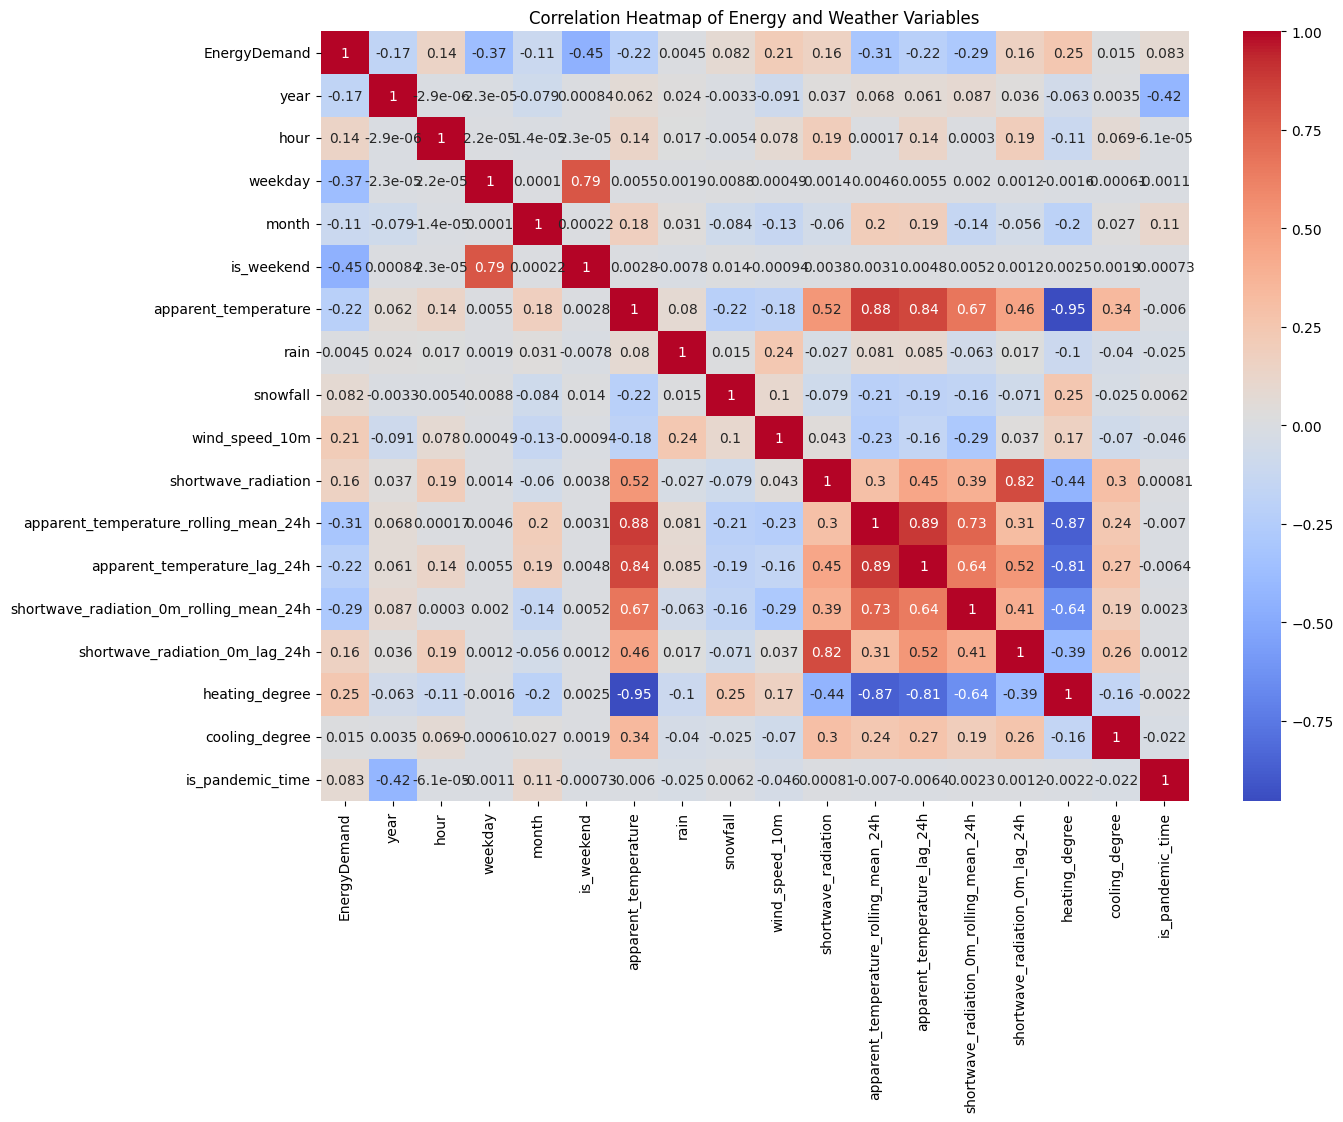

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# change the size of the plot
plt.figure(figsize=(14, 10))
energy_weather_corr = df_energy_weather.drop('DateUTC', axis=1).corr()
sns.heatmap(energy_weather_corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Energy and Weather Variables') 
plt.show()